In [1]:
# Import required libraries
import torch                                # pytorch
import torch.nn as nn                       # torch의 module, layer
import torch.optim as optim                 # torch의 Optimizer(SGD, Adam)
import torchvision                          # torch의 이미지 데이터 전처리(Resize, Normalize)
import torchvision.transforms as transforms # 변환
from torch.utils.data import DataLoader, random_split, Subset   # 필요한 data ex) MNIST 데이터 있는 부분 / 작은 학습데이터셋을 위한 Subset
import torch.nn.functional as F

from tqdm.autonotebook import tqdm

import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
from matplotlib.pyplot import imshow

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from pylib import train_network, set_seed

import os


/tmp/ipykernel_2535288/4248892476.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
import warnings
warnings.filterwarnings("ignore", "(Possibly )?corrupt EXIF data", UserWarning)

In [3]:
# cuda 사용을 위한 코드
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
torch.backends.cudnn.deterministic=True
set_seed(42)

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [4]:
# data augmentation 하는 부분
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),                    # 흑백 data channel = 1
    transforms.CenterCrop(128),
    transforms.Resize(130),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_val_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),                    # 흑백 data channel = 1
    transforms.Resize(130),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [5]:
from collections import Counter
import os

dir = '/home/hadoop/Roooselina/딥러닝 이해/data/xray_data'

for t in ['train', 'val', 'test']:
    split_path = os.path.join(dir, t)
    label_counts = {}
    for class_name in os.listdir(split_path):
        class_dir = os.path.join(split_path, class_name)
        label_counts[class_name] = len(os.listdir(class_dir))
    print(f"{t} 이미지 수:", label_counts)

train 이미지 수: {'PNEUMONIA': 3875, 'NORMAL': 1341}
val 이미지 수: {'PNEUMONIA': 8, 'NORMAL': 8}
test 이미지 수: {'PNEUMONIA': 390, 'NORMAL': 234}


In [6]:
# Hyperparameters

num_epochs = 10                            # 에포크 = 10

batch_size = 64                            # batch_size
learning_rate = 0.001                      # 학습률


In [7]:
dir = '/home/hadoop/Roooselina/딥러닝 이해/data/xray_data'

train_dataset = torchvision.datasets.ImageFolder(root = os.path.join(dir, 'train'), transform=transform_train)
val_dataset = torchvision.datasets.ImageFolder(root = os.path.join(dir, 'val'), transform=transform_val_test)
test_dataset = torchvision.datasets.ImageFolder(root = os.path.join(dir, 'test'), transform=transform_val_test)

# ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
from sklearn.model_selection import train_test_split

# 전체 데이터셋 불러오기 train/val/test 합침
#all_data = torchvision.datasets.ImageFolder(root=os.path.join(dir), transform=transform_train)  
#all_data.class_to_idx = {'NORMAL': 0, 'PNEUMONIA': 1}
#all_targets = all_data.targets
#all_indices = np.arange(len(all_targets))

# 각 데이터를 합친 후 7 : 1.5 : 1.5 로 데이터셋을 나눔
#train_idx, temp_idx, y_train, y_temp = train_test_split(all_indices, all_targets, test_size=0.3, stratify=all_targets, random_state=42)
#val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_temp, random_state=42)


#train_dataset = Subset(all_data, train_idx)
#val_dataset = Subset(all_data, val_idx)
#test_dataset = Subset(all_data, test_idx)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [8]:
# Define the CNN model for Xray Data
class XrayCNN(nn.Module):                                        # CNN class 선언 / nn.Module => 신경망 기본 클래스
    def __init__(self):
        super(XrayCNN, self).__init__()                                             # Super 초기화
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)    # Conv Layer1 channel(흑백) = 1
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)                             # MaxPooling 2 x 2
        self.dropout = nn.Dropout(0.3)                             # Dropout = 0.3

        self.global_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(128 * 4 * 4, 256)                   # Fully Connected Layer        
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):                                                       # 모델의 연산 순전파
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = self.global_pool(x)  # 4x4로 크기 줄이기
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [9]:
model = XrayCNN()
model.to(device)

from torchsummary import summary
summary(model, (1, 128, 128))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             320
       BatchNorm2d-2         [-1, 32, 128, 128]              64
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
       BatchNorm2d-5           [-1, 64, 64, 64]             128
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
       BatchNorm2d-8          [-1, 128, 32, 32]             256
         MaxPool2d-9          [-1, 128, 16, 16]               0
AdaptiveAvgPool2d-10            [-1, 128, 4, 4]               0
           Linear-11                  [-1, 256]         524,544
          Dropout-12                  [-1, 256]               0
           Linear-13                    [-1, 2]             514
Total params: 618,178
Trainable params:

In [10]:
# Retrieve middle layer weight and bias shapes
# FCLayer에 가중치와 벡터를 출력으로 확인
fc1_weight_shape = model.fc1.weight.shape                   # fc1의 weight 가중치
fc1_bias_shape = model.fc1.bias.shape                       # fc1의 bias 바이오스
print(f'FC1 Weight Shape: {fc1_weight_shape}, FC1 Bias Shape: {fc1_bias_shape}')

FC1 Weight Shape: torch.Size([256, 2048]), FC1 Bias Shape: torch.Size([256])


In [11]:
fc2_weight_shape = model.fc2.weight.shape                   # fc1의 weight 가중치
fc2_bias_shape = model.fc2.bias.shape                       # fc1의 bias 바이오스
print(f'FC2 Weight Shape: {fc2_weight_shape}, FC2 Bias Shape: {fc2_bias_shape}')

FC2 Weight Shape: torch.Size([2, 256]), FC2 Bias Shape: torch.Size([2])


In [16]:
# Track the best model 모델 생성

best_val_acc = 0                                            # 정확도
best_model = None                                           # 모델

# Training loop                                             # epoch 학습 루프 시작
for epoch in range(num_epochs):
    model.train()                                           # 모델을 train()
    running_loss = 0.0
    correct = 0                                             # 루프 중 정답
    total = 0                                               # 루프 총 total

    for images, labels in train_loader:                     # train 데이터셋을 불러와 사용 images와 label

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)                             # 위 코드에서 선언한 순전파 수행
        loss = criterion(outputs, labels)                   # 손실 함수 계산

        # Backward pass and optimization 역전파
        optimizer.zero_grad()                               # gradient 초기화
        loss.backward()                                     # 역전파
        optimizer.step()                                    # 옵티마이저 업데이트 (알맞은 가중치를 찾으며 학습하는 과정)

        # Track statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)           # 예측 결과 가장 높은 max의 data
        total += labels.size(0)
        correct += (predicted == labels).sum().item()       # 맞춘 정답의 개수 correct에 더함

    train_acc = 100 * correct / total                       # 학습한 정확도 계산
    avg_train_loss = running_loss / len(train_loader)       # 손실 loss 계산

    val_acc = 0
    val_loss = 0.0
    total = 0
    correct = 0

    # Validation step 검증 단계
    model.eval()                                            # model eval() 평가
    with torch.no_grad():                                   # gradient 계산 비활성화
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | '
          f'Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%')


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model.state_dict()                    # 정확도 갱신 저장

if best_model is not None:
    torch.save(best_model, 'best_cnn_model.pth')
    print(f'Best model saved with validation accuracy: {best_val_acc:.2f}%')

Epoch [1/10] | Train Loss: 0.0615 | Train Acc: 98.56% | Val Loss: 4.5911 | Val Acc: 50.00%
Epoch [2/10] | Train Loss: 0.0536 | Train Acc: 98.73% | Val Loss: 2.6090 | Val Acc: 43.75%
Epoch [3/10] | Train Loss: 0.0440 | Train Acc: 99.08% | Val Loss: 3.0299 | Val Acc: 50.00%
Epoch [4/10] | Train Loss: 0.0533 | Train Acc: 98.64% | Val Loss: 3.2088 | Val Acc: 37.50%
Epoch [5/10] | Train Loss: 0.0664 | Train Acc: 98.10% | Val Loss: 2.7237 | Val Acc: 50.00%
Epoch [6/10] | Train Loss: 0.0576 | Train Acc: 98.70% | Val Loss: 4.3993 | Val Acc: 50.00%
Epoch [7/10] | Train Loss: 0.0468 | Train Acc: 99.02% | Val Loss: 3.0699 | Val Acc: 50.00%
Epoch [8/10] | Train Loss: 0.0488 | Train Acc: 99.00% | Val Loss: 3.6033 | Val Acc: 50.00%
Epoch [9/10] | Train Loss: 0.0434 | Train Acc: 99.00% | Val Loss: 2.4469 | Val Acc: 50.00%
Epoch [10/10] | Train Loss: 0.0399 | Train Acc: 99.10% | Val Loss: 2.3884 | Val Acc: 31.25%
Best model saved with validation accuracy: 50.00%


In [17]:
# Test the model
model.load_state_dict(torch.load('best_cnn_model.pth'))               # Best model 불러옴
model.eval()                                    # 모델 eval() 평가
model.to(device)                                 # Gpu 설정

correct = 0
total = 0
all_preds = []                                  # 예측결과
all_labels = []                                 # labels
test_images = []                                # images

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        test_images.extend(images.cpu().numpy())

test_acc = 100 * correct / total
print(f'Test Accuracy: {test_acc:.2f}%')


/tmp/ipykernel_2535288/3875796185.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_cnn_model.pth'))               # Best model 불러옴


Test Accuracy: 45.99%


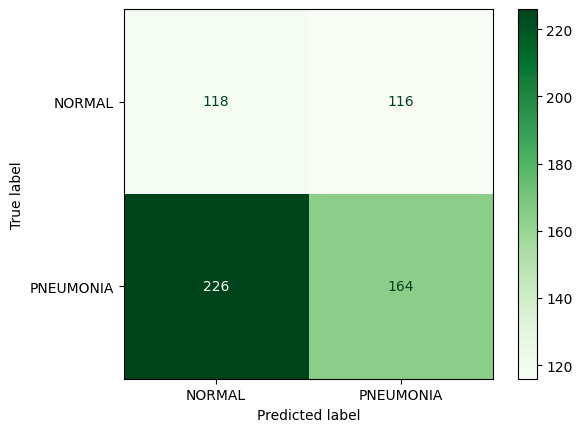

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NORMAL', 'PNEUMONIA'])
disp.plot(cmap=plt.cm.Greens)
plt.show()
